# Analiza danych - Iris Dataset (Fisher, 1936)
## Cel projektu:
### Analiza klasycznego zbióru danych Fishera na temat kwiatów irysów, należy użyć biblioteki Pandas, wyciągnąć wnioski i opatrzyć raport wizualizacjami.

# Wczytanie i eksploracja danych

In [18]:
import pandas as pd
import matplotlib.pyplot as plt


In [19]:
df = pd.read_csv('25__iris.csv', sep=",")
df

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width),klasa (class)
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Podgląd danych

In [20]:
df.isnull()

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width),klasa (class)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   długość kielicha (sepal length)   150 non-null    float64
 1   szerokość kielicha (sepal width)  150 non-null    float64
 2   długość płatka (petal length)     150 non-null    float64
 3   szerokość płatka (petal width)    150 non-null    float64
 4   klasa (class)                     150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [22]:
df.describe

<bound method NDFrame.describe of      długość kielicha (sepal length)  szerokość kielicha (sepal width)  \
0                                5.1                               3.5   
1                                4.9                               3.0   
2                                4.7                               3.2   
3                                4.6                               3.1   
4                                5.0                               3.6   
..                               ...                               ...   
145                              6.7                               3.0   
146                              6.3                               2.5   
147                              6.5                               3.0   
148                              6.2                               3.4   
149                              5.9                               3.0   

     długość płatka (petal length)  szerokość płatka (petal width)  \
0      

In [23]:
df.nunique()

długość kielicha (sepal length)     35
szerokość kielicha (sepal width)    23
długość płatka (petal length)       43
szerokość płatka (petal width)      22
klasa (class)                        3
dtype: int64

In [24]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [25]:
df.columns

Index(['długość kielicha (sepal length)', 'szerokość kielicha (sepal width)',
       'długość płatka (petal length)', 'szerokość płatka (petal width)',
       'klasa (class)'],
      dtype='object')

In [26]:
df['klasa (class)'].value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: klasa (class), dtype: int64

array([[<Axes: title={'center': 'długość kielicha (sepal length)'}>,
        <Axes: title={'center': 'szerokość kielicha (sepal width)'}>],
       [<Axes: title={'center': 'długość płatka (petal length)'}>,
        <Axes: title={'center': 'szerokość płatka (petal width)'}>]],
      dtype=object)

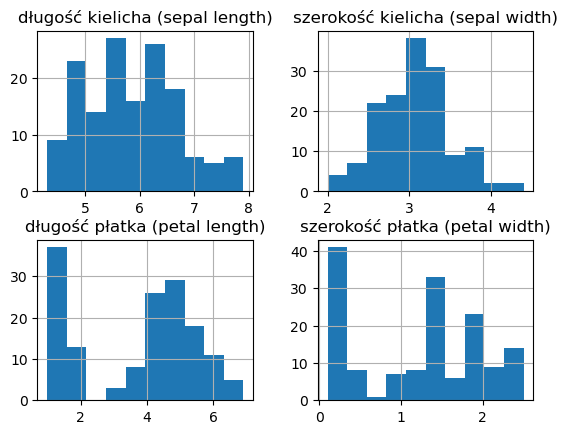

In [27]:
df.hist()

## Opis danych

Zestaw obejmuje cechy morfologiczne trzech gatunków irysów:
- długość kielicha (sepal length) [cm]
- szerokość kielicha (sepal width) [cm]
- długość płatka (petal length) [cm]
- szerokość płatka (petal width) [cm]
- klasa (class): Iris-setosa, Iris-versicolor, Iris-virginica

## Wnioski z analizy podstawowych statystyk:
Zbiór danych jest kompletny i dobrze zorganizowany, nie ma braków danych.
Każda klasa (gatunek) jest reprezentowana porównywalną liczbą próbek (ok. 50 dla każdego gatunku).

# Analiza cech wg gatunku

In [28]:
df.groupby('klasa (class)').mean()

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width)
klasa (class),,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


## średnia długość płatka irysa w zależności od gatunku LINE PLOT

<Axes: xlabel='klasa (class)'>

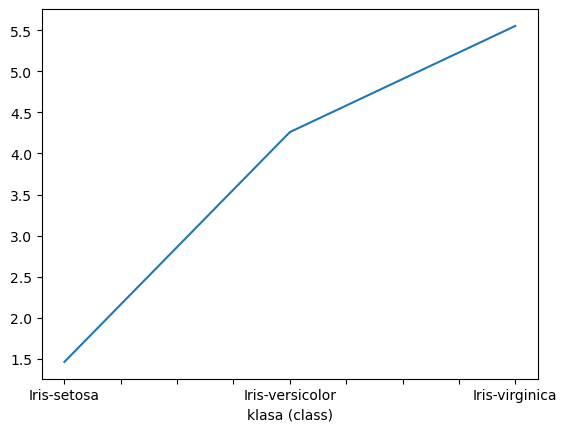

In [29]:
df.groupby('klasa (class)')['długość płatka (petal length)'].mean().plot(kind='line')


## średnia szerokość płatka w trzech gatunkach  BAR PLOT


<Axes: xlabel='klasa (class)'>

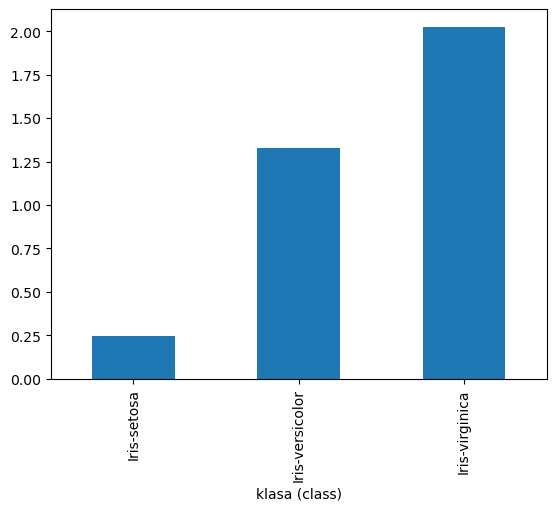

In [30]:
df.groupby('klasa (class)')['szerokość płatka (petal width)'].mean().plot(kind='bar')



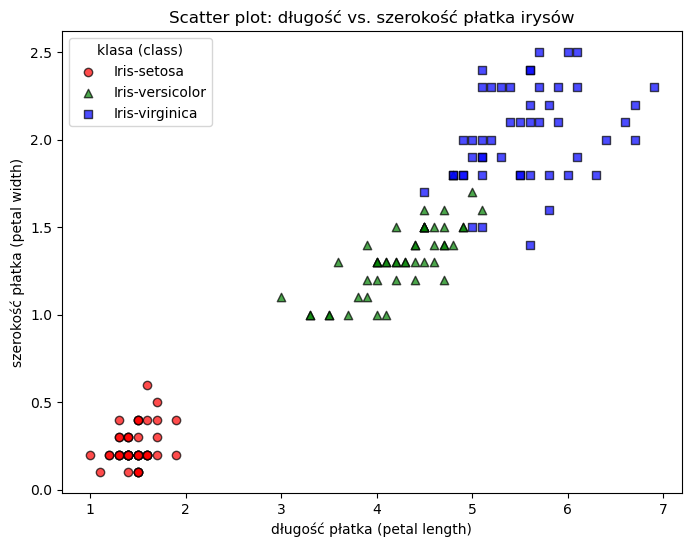

In [34]:

kategorie = df['klasa (class)'].unique()  
kolory = ['red', 'green', 'blue']
markery = ['o', '^', 's']

plt.figure(figsize=(8,6))
for kat, kolor, marker in zip(kategorie, kolory, markery):
    podzbior = df[df['klasa (class)'] == kat]  
    plt.scatter(
        podzbior['długość płatka (petal length)'],
        podzbior['szerokość płatka (petal width)'],
        label=kat,
        color=kolor,
        marker=marker,
        edgecolor='black',
        alpha=0.7
    )

plt.xlabel('długość płatka (petal length)')
plt.ylabel('szerokość płatka (petal width)')
plt.title('Scatter plot: długość vs. szerokość płatka irysów')
plt.legend(title='klasa (class)')
plt.show()


### Obserwacje:
Iris-setosa cechuje sie wyraznie mniejszymi rozmiarami płatkow niż pozostale gatunki.
Najwieksze wartości dla wszystkich cech wystepuja u Iris-virginica.
Iris-versicolor i Iris-virginica mają bardziej zbliżone do siebie rozmiary, lecz Virginica wyraźnie wyprzedza pozostałe gatunki pod względem wymiarów płatków i długości kielicha.



# Analiza korelacji (macierz korelacji)

In [16]:
df.corr(numeric_only=True)

,długość kielicha (sepal length),szerokość kielicha (sepal width),długość płatka (petal length),szerokość płatka (petal width)
długość kielicha (sepal length),1.000000,-0.109369,0.871754,0.817954
szerokość kielicha (sepal width),-0.109369,1.000000,-0.420516,-0.356544
długość płatka (petal length),0.871754,-0.420516,1.000000,0.962757
szerokość płatka (petal width),0.817954,-0.356544,0.962757,1.000000


### Interpretacja:

- Bardzo silna zależność występuje między długością a szerokością płatka-(0.96)
Jeśli jeden płatek jest dłuższy, to zazwyczaj jest też szerszy. Oznacza to, że te dwa pomiary prawie zawsze „rosną razem” – im bardziej okazały płatek, tym większy zarówno na długość, jak i na szerokość.
- Średnia, ale zauważalna zależność występuje między długością kielicha a długością płatka:
Kwiaty, które mają dłuższe kielichy, często mają też dłuższe płatki, ale to połączenie nie jest tak mocne jak w poprzednim przypadku. Tutaj rosną one raczej w podobnym tempie, chociaż nie zawsze idealnie razem.
- Korelacja ujemna to sytuacja, gdzie jedna cecha rośnie, a druga maleje. To oznacza, że kwiat o bardzo długim kielichu ma raczej węższy kielich, czyli te wielkości nie rosną razem, tylko odwrotnie.

# Podsumowanie

- Dane są rzetelne i kompletne:
W zbiorze nie brakuje żadnych informacji. Każdy gatunek kwiatu ma tyle samo przykładów, więc łatwo je porównać.
- Długość płatka świetnie odróżnia gatunki:
Najłatwiej rozpoznać, do którego gatunku należy kwiat, patrząc właśnie na długość jego płatka. Kwiaty Iris-setosa już na pierwszy rzut oka wyróżniają się pod tym względem.
- Możliwe jest znalezienie najważniejszych różnic na podstawie liczb. Wystarczy porównywać wartości liczbowe i sprawdzać zależności między nimi.
